# Análisis de duplicados - Bases de datos INER COVID-19:

* `INER_COVID19_CostoPacientes_Econo.csv`
* `INER_COVID19_Pacientes_DiagnosticoComorbilidad.csv` 
* `INER_COVID19_TrabajoSocial.csv` 

Cargaremos los 3 archivos y realizaremos un análisis de duplicados en cada uno de ellos y de manera cruzada para detectar si hay registros que se repiten en más de un archivo y tener la base ground truth para el etiquetado de pares positivos en el proceso de entrenamiento del modelo de Ligado de Registros

## 1. Carga de datos 

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import unicodedata
from math import comb

ruta_base = Path().absolute().parent
ruta_datos = ruta_base / 'data'
archivo_1 = 'INER_COVID19_CostoPacientes_Econo.csv'
archivo_2 = 'INER_COVID19_Pacientes_DiagnosticoComorbilidad.csv'
archivo_3 = 'INER_COVID19_TrabajoSocial.csv'

df_economico = pd.read_csv(ruta_datos / archivo_1)
df_comorbilidad = pd.read_csv(ruta_datos / archivo_2)
df_trabajo_social = pd.read_csv(ruta_datos / archivo_3)
# Quitamos columna Unamed: 19 de CSV Trabajo Social
df_trabajo_social = df_trabajo_social.loc[:, ~df_trabajo_social.columns.str.contains('^Unnamed')]

# Conversión de fechas
df_economico['FECHA_INGRESO_INER']        = pd.to_datetime(df_economico['FECHA_INGRESO_INER'],        errors='coerce')
df_economico['FECHA_DE_ALTA_MEJORIA']      = pd.to_datetime(df_economico['FECHA_DE_ALTA_MEJORIA'],      errors='coerce')
df_comorbilidad['fechaing']                = pd.to_datetime(df_comorbilidad['fechaing'],                errors='coerce')
df_trabajo_social['FECHA DE ELABORACIÓN'] = pd.to_datetime(df_trabajo_social['FECHA DE ELABORACIÓN'], format='mixed', dayfirst=True, errors='coerce')


## 2. Panorama general

Se muestra el número de registros por CSV y el total en conjunto. 

Estos valores sirven como referencia para dimensionar la magnitud del problema de duplicados en las secciones siguientes.


In [4]:
N_economico = len(df_economico)
N_comorbilidad = len(df_comorbilidad)
N_trabajo_social = len(df_trabajo_social)
N_total = N_economico + N_comorbilidad + N_trabajo_social
resumen_panorama = pd.DataFrame([
    {'CSV': 'Económico',      'Archivo': archivo_1, 'Registros': N_economico},
    {'CSV': 'Comorbilidad',   'Archivo': archivo_2, 'Registros': N_comorbilidad},
    {'CSV': 'Trabajo Social', 'Archivo': archivo_3, 'Registros': N_trabajo_social},
    {'CSV': 'Total',          'Archivo': ' ',       'Registros': N_total},
])
display(
    resumen_panorama.style
    .bar(subset=['Registros'], color='#1428a7', vmin=0)
    .set_caption('Registros por CSV')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

CSV,Archivo,Registros
Económico,INER_COVID19_CostoPacientes_Econo.csv,4632
Comorbilidad,INER_COVID19_Pacientes_DiagnosticoComorbilidad.csv,4278
Trabajo Social,INER_COVID19_TrabajoSocial.csv,14796
Total,,23706


## 3. Registros duplicados intra-CSV

Se analizan los duplicados dentro de cada CSV de forma independiente usando dos estrategias: 
* Detección de filas exactamente idénticas
* Detección por llave lógica (combinación de campos clave)

Ambas perspectivas son complementarias: la primera es estricta, la segunda tolera diferencias en campos secundarios.


### 3.1 Duplicados exactos (`df.duplicated()`)

Se detectan filas donde todos los campos son idénticos. Este es el criterio más estricto de duplicidad y al mismo tiempo el enfoque más débil semánticamente, ya que pequeñas diferencias a nivel de caracteres en los campos pueden hacer que un registro sea considerado una persona diferente aunque en realidad se trate del mismo paciente.

In [ ]:

resumen_dup = []
for nombre, df in {
    'Económico':      df_economico,
    'Comorbilidad':   df_comorbilidad,
    'Trabajo Social': df_trabajo_social
}.items():
    total = len(df)
    dups  = df.duplicated().sum()
    resumen_dup.append({'CSV': nombre, 'Total filas': total,
                        'Filas duplicadas': dups, 'Proporción': dups / total})

display(
    pd.DataFrame(resumen_dup).style
    .format({'Proporción': '{:.2%}', 'Total filas': '{:,}', 'Filas duplicadas': '{:,}'})
    .bar(subset=['Filas duplicadas'], color='#1428a7', vmin=0)
    .set_caption('Duplicados exactos por CSV')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

# Muestra de filas duplicadas en Comorbilidad (el CSV con más duplicados)
if df_comorbilidad.duplicated().any():
    display(
        df_comorbilidad[df_comorbilidad.duplicated(keep=False)]
        .sort_values(by=list(df_comorbilidad.columns[:3]))
        .head(6)
        .style.set_caption('Muestra de filas duplicadas — Comorbilidad')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.0em; font-weight:bold'}])
    )


CSV,Total filas,Filas duplicadas,Proporción
Económico,"4,632",1,0.02%
Comorbilidad,"4,278",0,0.00%
Trabajo Social,"14,796",0,0.00%


### 3.2 Duplicados por llave: Nombre

Se identifican todos los registros que comparten el mismo nombre dentro de cada CSV. Esta llave es la más amplia y equivale al análisis documentado en los EDA individuales: captura tanto re-ingresos legítimos como errores de captura, sin distinguir entre ellos. Sirve como cota superior del problema de duplicidad por identidad.


In [61]:
# Funciones auxiliares para análisis por llave lógica
def normalizar_llave(valor):
    if pd.isna(valor):
        return valor
    return " ".join(str(valor).strip().split())

def analizar_duplicados(df, llave, nombre_dataset):
    df_tmp = df.copy()
    llave_norm = []
    for col in llave:
        if df_tmp[col].dtype == 'object':
            col_norm = f'_llave_{col}'
            df_tmp[col_norm] = df_tmp[col].apply(normalizar_llave)
            llave_norm.append(col_norm)
        else:
            llave_norm.append(col)

    mask_dup = df_tmp.duplicated(subset=llave_norm, keep=False)
    n_dup = mask_dup.sum()

    if n_dup == 0:
        print(f"{nombre_dataset}: sin duplicados por llave ({' + '.join(llave)})")
        return

    df_dup = df_tmp[mask_dup].copy()
    df_dup['fila_csv'] = df_dup.index + 2

    conteo = df_dup.groupby(llave_norm, dropna=False).size().value_counts().sort_index()
    resumen = pd.DataFrame([
        {'Apariciones por grupo': n_reps, 'Grupos': n_grupos}
        for n_reps, n_grupos in conteo.items()
    ])
    display(
        resumen.style
        .set_caption(f'CSV {nombre_dataset} — {n_dup} registros duplicados por ({", ".join(llave)})')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.0em; font-weight:bold'}])
        .hide(axis='index')
    )

    cols_auxiliares = {c for c in df_tmp.columns if c.startswith('_llave_') or c.endswith(('_limpio', '_std'))}
    cols_no_llave = [c for c in df.columns if c not in set(llave) | cols_auxiliares]
    cols_con_diferencias = [
        c for c in cols_no_llave
        if df_dup.groupby(llave_norm, dropna=False)[c].nunique(dropna=False).max() > 1
    ]

    cols_mostrar = ['fila_csv'] + list(llave) + cols_con_diferencias
    df_detalle = df_dup.sort_values(by=llave_norm)[cols_mostrar].head(10)

    def highlight_diff(df):
        style = pd.DataFrame('', index=df.index, columns=df.columns)
        for col in cols_con_diferencias:
            if col not in df.columns:
                continue
            for _, grupo in df.groupby(list(llave), dropna=False):
                if grupo[col].nunique(dropna=False) > 1:
                    style.loc[grupo.index, col] = 'background-color: #a71414'
        return style

    if cols_con_diferencias:
        display(
            df_detalle.style
            .apply(highlight_diff, axis=None)
            .set_caption('Columnas con diferencias entre duplicados (10 filas de muestra)')
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.0em; font-weight:bold; text-align:left'}])
            .hide(axis='index')
        )
    else:
        display(
            df_detalle.style
            .set_caption('Detalle — filas 100% idénticas')
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.0em; font-weight:bold; text-align:left'}])
            .hide(axis='index')
        )

In [62]:
analizar_duplicados(df_economico, ['NOMBRE_DEL_PACIENTE'], 'Económico')
analizar_duplicados(df_comorbilidad, ['nombre'], 'Comorbilidad')

df_ts_temp = df_trabajo_social.copy()
for col in ['APELLIDO PATERNO', 'APELLIDO MATERNO', 'NOMBRE']:
    df_ts_temp[col] = df_ts_temp[col].fillna('').str.strip().str.upper()
df_ts_temp['NOMBRE_COMPLETO'] = (
    df_ts_temp['APELLIDO PATERNO'] + " " +
    df_ts_temp['APELLIDO MATERNO'] + " " +
    df_ts_temp['NOMBRE']
)
analizar_duplicados(df_ts_temp, ['NOMBRE_COMPLETO'], 'Trabajo Social')


Apariciones por grupo,Grupos
2,141
3,24
4,8
5,1
7,1


fila_csv,NOMBRE_DEL_PACIENTE,EXP,SEXO,EDAD,GRUPO_EDAD,RESULTADO,ETIQUETAS_COVID,MOTIVO_DE_EGRESO,FECHA_INGRESO_INER,FECHA_DE_ALTA_MEJORIA,DIAS_ESTANCIA,GASTO_TOTAL,GASTO_DIARIO,TOTAL_DE_INGRESOS,TOTAL_DE_EGRESOS,ESCOLARIDAD,OCUPACION,DERECHOHABIENTE_Y/O_BENEFICIARIO,VULNERABILIDAD_SOCIOECONOMICA,NIVEL_SOCIOECONOMICO,ESTADO_RESIDENCIA,CLAVE_GEOESTADISTICA_ESTATAL,MUNICIPIO_RESIDENCIA,CLAVE_GEOESTADISTICA_MUNICIPAL
2325,ACEVEDO SANCHEZ GABRIEL,240935,M,36.000000,35-39,SARS-COV2,nan,ALTA POR MEJORIA,2021-08-18 00:00:00,2021-08-19 00:00:00,1,54857.839900,54857.839900,5000.000000,4985.000000,PRIMARIA,nan,NINGUNO,True,2E,CIUDAD DE MEXICO,9.000000,IZTAPALAPA,7.000000
2478,ACEVEDO SANCHEZ GABRIEL,240935,M,36.000000,35-39,NEG SARS-COV2,POSTCOVID,ALTA POR MEJORIA,2021-08-24 00:00:00,2021-09-01 00:00:00,8,142317.880000,17789.735000,5000.000000,4985.000000,PRIMARIA,nan,NINGUNO,True,2E,CIUDAD DE MEXICO,9.000000,IZTAPALAPA,7.000000
382,ACOSTA SOTO MIGUEL ANGEL,233448,M,46.000000,45-49,SARS-COV2,COVID,ALTA POR MEJORIA,2022-02-09 00:00:00,2022-02-20 00:00:00,11,176282.490000,16025.680909,nan,nan,nan,nan,NINGUNO,False,nan,CIUDAD DE MEXICO,9.000000,TLALPAN,12.000000
489,ACOSTA SOTO MIGUEL ANGEL,233448,M,46.000000,45-49,SARS-COV2,COVID,ALTA POR MEJORIA,2022-02-21 00:00:00,2022-03-01 00:00:00,8,152719.130000,19089.891250,nan,nan,nan,nan,NINGUNO,False,nan,CIUDAD DE MEXICO,9.000000,TLALPAN,12.000000
576,AGUILAR ACEVEDO MIGUEL,241392,M,61.000000,60-64,NEG SARS-COV2,POSTCOVID+VCOVID,ALTA POR MEJORIA,2022-04-08 00:00:00,2022-04-27 00:00:00,19,333804.479430,17568.656812,8000.000000,7143.000000,SECUNDARIA,nan,NINGUNO,True,2E,MEXICO,15.000000,TLALNEPANTLA DE BAZ,104.000000
586,AGUILAR ACEVEDO MIGUEL,241392,M,61.000000,60-64,NEG SARS-COV2,POSTCOVID+VCOVID,ALTA POR MEJORIA,2022-05-12 00:00:00,2022-05-27 00:00:00,15,258156.713020,17210.447535,8000.000000,7143.000000,SECUNDARIA,nan,NINGUNO,True,2E,MEXICO,15.000000,TLALNEPANTLA DE BAZ,104.000000
2796,AGUILAR ACEVEDO MIGUEL,241392,M,60.000000,60-64,SARS-COV2,COVID+VCOVID,ALTA POR MEJORIA,2021-10-14 00:00:00,2021-11-16 00:00:00,33,648975.045100,19665.910458,8000.000000,7143.000000,SECUNDARIA,nan,NINGUNO,True,2E,MEXICO,15.000000,TLALNEPANTLA DE BAZ,104.000000
415,ALANIS MALAGON PABLO ROGELIO,241875,M,57.000000,55-59,SARS-COV2,COVID+VCOVID,ALTA POR MEJORIA,2021-02-08 00:00:00,2022-02-22 00:00:00,14,253503.380000,18107.384286,39000.000000,22300.000000,PROFESIONAL,nan,IMSS,False,5,CIUDAD DE MEXICO,9.000000,ALVARO OBREGON,10.000000
2963,ALANIS MALAGON PABLO ROGELIO,241875,M,58.000000,55-59,SARS-COV2,COVID+VCOVID,ALTA POR MEJORIA,2021-12-09 00:00:00,2021-12-28 00:00:00,19,396747.320000,20881.437895,39000.000000,22300.000000,PROFESIONAL,nan,IMSS,False,5,CIUDAD DE MEXICO,9.000000,ALVARO OBREGON,10.000000
2101,ALARCON MENDOZA MARIA VIRGINIA,240625,F,74.000000,70-74,SARS-COV2,nan,ALTA POR MEJORIA,2021-07-09 00:00:00,2021-07-13 00:00:00,4,76850.064000,19212.516000,13500.000000,9860.000000,ALFABETA,nan,NINGUNO,False,3,CIUDAD DE MEXICO,9.000000,BENITO JUAREZ,14.000000


Apariciones por grupo,Grupos
2,108
3,5
4,2
5,1


fila_csv,nombre,expediente,fechaing,fechaegr,diagnosticoprincipal,cie101,diagnostico2,cie102,diagnostico3,cie103,diagnostico4,cie104,dx2,dx3,dx4,obesidad,obesidad1,cardiopatia,comorbi,diabetes,nefropatia,eaperge,tephap,comorbicv
1027,ABEL GONZALEZ HERNANDEZ,238389,2020-08-23 00:00:00,2020-10-13,INFECCION RESPIRATORIA AGUDA POR SARS COV2,U07.1,OBESIDAD,E66.9,nan,nan,nan,nan,E66.9,nan,nan,1.000000,0.000000,0.000000,Obesidad/Trastornos alimentación,0.000000,0.000000,0.000000,0.000000,0.0
1646,ABEL GONZALEZ HERNANDEZ,238389,2021-01-17 00:00:00,2021-01-19,SARS-COV2,U07.1,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.000000,Ninguna,0.000000,0.000000,0.000000,0.000000,0.0
839,ABRAHAM SANCHEZ VALDEPE?A,238486,2020-09-06 00:00:00,2020-09-07,NEUMONIA POR SARS COV2,U07.1,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.000000,Ninguna,0.000000,0.000000,0.000000,0.000000,0.0
970,ABRAHAM SANCHEZ VALDEPE?A,238486,2020-09-14 00:00:00,2020-10-02,NEUMONIA POR SARS COV2,U07.1,ESTENOSIS TRAQUEAL,J39.8,nan,nan,nan,nan,J39.8,nan,nan,0.000000,0.000000,0.000000,Otras,0.000000,0.000000,0.000000,0.000000,0.0
3158,AIDA IMELDA VALERO CHAVEZ,239109,2021-09-22 00:00:00,2021-09-25,ANTECEDENTES DE NEUMONIA POR SARS COV2,U07.1,ESTENOSIS SUBGLOTICA,J38.6,HAS,I10.X,DIABETES MELLITUS TIPO II,E11.9,J38.6,I10.X,E11.9,0.000000,0.000000,1.000000,Diabetes Mellitus,1.000000,0.000000,0.000000,0.000000,HTAS
4276,AIDA IMELDA VALERO CHAVEZ,239109,2023-12-18 00:00:00,2023-12-20,POST COVID,U09.9,ESTENOSIS SUBGLOTICA,J38.6,HAS,I10.X,DIABETES MELLITUS TIPO II,E11.9,J38.6,I10.X,E11.9,0.000000,0.000000,1.000000,Diabetes Mellitus,1.000000,0.000000,0.000000,0.000000,HTAS
3701,ALBERTO GARCIA RAMIREZ,242473,2022-02-04 00:00:00,2022-02-11,NEUMONIA POR SARS COV2,U07.1,ENFERMEDAD PULMONAR INTERSTICIAL,J84.9,INSUFICIENCIA RESPIRATORIA TIPO II,J96.1,nan,nan,J84.9,J96.1,nan,0.000000,0.000000,0.000000,Otras,0.000000,0.000000,0.000000,0.000000,0.0
3807,ALBERTO GARCIA RAMIREZ,242473,2022-02-17 00:00:00,2022-03-04,NEUMONIA POR SARS COV2,U07.1,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.000000,Ninguna,0.000000,0.000000,0.000000,0.000000,0.0
3888,ALBERTO GARCIA RAMIREZ,242473,2022-04-19 00:00:00,2022-05-02,NEUMONIA POR SARS COV2,U07.1,ENFERMEDAD PULMONAR INTERSTICIAL,J84.9,nan,nan,nan,nan,J84.9,nan,nan,0.000000,0.000000,0.000000,Otras,0.000000,0.000000,0.000000,0.000000,0.0
3897,ALBERTO GARCIA RAMIREZ,242473,2022-05-09 00:00:00,2022-05-18,NEUMONIA POR SARS COV2,U07.1,ENFERMEDAD PULMONAR INTERSTICIAL,J84.9,nan,nan,nan,nan,J84.9,nan,nan,0.000000,0.000000,0.000000,Otras,0.000000,0.000000,0.000000,0.000000,0.0


Apariciones por grupo,Grupos
2,12


fila_csv,NOMBRE_COMPLETO,AÑO,FILA,EXPEDIENTE,NO. HISTORIA,FECHA DE ELABORACIÓN,EDAD,FECHA DE NACIMIENTO,GENERO,DIAGNOSTICO,ESCOLARIDAD,OCUPACIÓN,DERECHOHABIENTE Y/O BENEFICIARIO,DELEGACIÓN O MUNICIPIO PERMANENTE,ESTADO / PAIS PERMANENTE,TOTAL DE PUNTOS,NIVEL SOCIOECONÓMICO
1772,FLORES MENDOZA ROBERTO,0,1770,238015,IAN614217,2020-06-18 23:36:00,52 años 9 meses 16 días,1967-09-03,Masculino,Enfermedad respiratoria aguda con contacto o sospecha de exposición a COVID-19,NMS INCOMPLETO,CARPINTERO,NINGUNO,Azcapotzalco,"Ciudad de México,Mexico",29,2
10215,FLORES MENDOZA ROBERTO,2,4499,246529,IAN703539,2022-09-27 00:00:00,65 Años,1957-09-25,Masculino,nan,Técnico,Técnicos y Profesionales de nivel medio,nan,Ninguno,CUAJIMALPA DE MORELOS,CIUDAD DE MÉXICO,34
5002,GARCIA GONZALEZ CIRILO,1,1965,241296,IAN655063,2021-01-10 13:55:00,74 años 6 meses 18 días,1947-03-16,Masculino,nan,PRIMARIA COMPLETA,AUX ADMON,ISSSTE,Cuajimalpa de Morelos,"Ciudad de México,Mexico",21,2
10564,GARCIA GONZALEZ CIRILO,2,4848,246880,IAN705760,2022-10-18 00:00:00,73 Años,1949-06-12,Masculino,nan,Primaria Incompleta,Sin ocupación,Ninguno,MILPA ALTA,CIUDAD DE MÉXICO,8,1X
1366,GARCIA PEREZ GUADALUPE,0,1364,237588,IAN610906,2020-04-22 12:04:00,61 años 4 meses 11 días,1958-12-12,Masculino,Enfermedad respiratoria aguda con contacto o sospecha de exposición a COVID-19,PRIMARIA INCOMPLETA,COSTURERA,NINGUNO,Iztapalapa,"Ciudad de México,Mexico",22,1
5795,GARCIA PEREZ GUADALUPE,2,79,242094,IAN560818,2022-03-01 17:36:00,53 años 2 meses 24 días,1968-10-12,Femenino,Enfermedad respiratoria aguda con contacto o sospecha de exposición a COVID-19,SECUNDARIA COMPLETA,COSTURERA,NINGUNO,Iztapalapa,"Ciudad de México,Mexico",20,1E
325,GONZALEZ GARCIA JOSE LUIS,0,323,236544,IAN602397,2020-01-18 02:44:00,48 años 5 meses 2 días,1971-08-18,Masculino,"Neumonía, organismo no especificado",NMS COMPLETO,COMERCIANTE AMBULANTE,NINGUNO,Tlalpan,"Ciudad de México,Mexico",32,2
326,GONZALEZ GARCIA JOSE LUIS,0,324,236544,IAN602397,2020-01-18 02:44:00,48 años 5 meses 2 días,1971-08-18,Masculino,"Neumonía, organismo no especificado",NMS COMPLETO,COMERCIANTE AMBULANTE,NINGUNO,Tlalpan,"Ciudad de México,Mexico",32,2
6133,HERNANDEZ GARCIA ENRIQUE,2,417,242435,IAN680486,2022-01-31 10:49:00,57 años 6 meses 16 días,1964-07-16,Masculino,"Tuberculosis respiratoria, no confirmada bacteriológica o histológicamente",CARR. TEC. DESP. DE SEC.,INCAPACITADO,NINGUNO,Tláhuac,"Ciudad de México,Mexico",22,1E
6689,HERNANDEZ GARCIA ENRIQUE,2,973,242996,IAN686512,2022-03-21 00:00:00,nan,nan,nan,nan,Secundaria Completa,nan,Ninguno,IZTAPALAPA,CIUDAD DE MÉXICO,11,1XE


### 3.3 Duplicados por llave: Nombre + Expediente

Se agrega el expediente como segundo criterio. Esta llave refina el análisis: registros con mismo nombre y mismo expediente son casi con certeza el mismo paciente (re-ingreso o error de captura), mientras que mismo nombre con expedientes distintos señala posibles homónimos o errores en la asignación del expediente — como se observa en Trabajo Social.



In [63]:
analizar_duplicados(df_economico, ['NOMBRE_DEL_PACIENTE', 'EXP'], 'Económico')

analizar_duplicados(df_comorbilidad, ['nombre', 'expediente'], 'Comorbilidad')

df_ts_temp = df_trabajo_social.copy()
for col in ['APELLIDO PATERNO', 'APELLIDO MATERNO', 'NOMBRE']:
    df_ts_temp[col] = df_ts_temp[col].fillna('').str.strip().str.upper()
df_ts_temp['NOMBRE_COMPLETO'] = (
    df_ts_temp['APELLIDO PATERNO'] + " " +
    df_ts_temp['APELLIDO MATERNO'] + " " +
    df_ts_temp['NOMBRE']
)
analizar_duplicados(df_ts_temp, ['NOMBRE_COMPLETO', 'EXPEDIENTE'], 'Trabajo Social')

Apariciones por grupo,Grupos
2,133
3,24
4,8
5,1
7,1


fila_csv,NOMBRE_DEL_PACIENTE,EXP,SEXO,EDAD,GRUPO_EDAD,RESULTADO,ETIQUETAS_COVID,MOTIVO_DE_EGRESO,FECHA_INGRESO_INER,FECHA_DE_ALTA_MEJORIA,DIAS_ESTANCIA,GASTO_TOTAL,GASTO_DIARIO,TOTAL_DE_INGRESOS,TOTAL_DE_EGRESOS,ESCOLARIDAD,OCUPACION,DERECHOHABIENTE_Y/O_BENEFICIARIO,VULNERABILIDAD_SOCIOECONOMICA,NIVEL_SOCIOECONOMICO,ESTADO_RESIDENCIA,CLAVE_GEOESTADISTICA_ESTATAL,MUNICIPIO_RESIDENCIA,CLAVE_GEOESTADISTICA_MUNICIPAL
2325,ACEVEDO SANCHEZ GABRIEL,240935,M,36.000000,35-39,SARS-COV2,nan,ALTA POR MEJORIA,2021-08-18 00:00:00,2021-08-19 00:00:00,1,54857.839900,54857.839900,5000.000000,4985.000000,PRIMARIA,nan,NINGUNO,True,2E,CIUDAD DE MEXICO,9.000000,IZTAPALAPA,7.000000
2478,ACEVEDO SANCHEZ GABRIEL,240935,M,36.000000,35-39,NEG SARS-COV2,POSTCOVID,ALTA POR MEJORIA,2021-08-24 00:00:00,2021-09-01 00:00:00,8,142317.880000,17789.735000,5000.000000,4985.000000,PRIMARIA,nan,NINGUNO,True,2E,CIUDAD DE MEXICO,9.000000,IZTAPALAPA,7.000000
382,ACOSTA SOTO MIGUEL ANGEL,233448,M,46.000000,45-49,SARS-COV2,COVID,ALTA POR MEJORIA,2022-02-09 00:00:00,2022-02-20 00:00:00,11,176282.490000,16025.680909,nan,nan,nan,nan,NINGUNO,False,nan,CIUDAD DE MEXICO,9.000000,TLALPAN,12.000000
489,ACOSTA SOTO MIGUEL ANGEL,233448,M,46.000000,45-49,SARS-COV2,COVID,ALTA POR MEJORIA,2022-02-21 00:00:00,2022-03-01 00:00:00,8,152719.130000,19089.891250,nan,nan,nan,nan,NINGUNO,False,nan,CIUDAD DE MEXICO,9.000000,TLALPAN,12.000000
576,AGUILAR ACEVEDO MIGUEL,241392,M,61.000000,60-64,NEG SARS-COV2,POSTCOVID+VCOVID,ALTA POR MEJORIA,2022-04-08 00:00:00,2022-04-27 00:00:00,19,333804.479430,17568.656812,8000.000000,7143.000000,SECUNDARIA,nan,NINGUNO,True,2E,MEXICO,15.000000,TLALNEPANTLA DE BAZ,104.000000
586,AGUILAR ACEVEDO MIGUEL,241392,M,61.000000,60-64,NEG SARS-COV2,POSTCOVID+VCOVID,ALTA POR MEJORIA,2022-05-12 00:00:00,2022-05-27 00:00:00,15,258156.713020,17210.447535,8000.000000,7143.000000,SECUNDARIA,nan,NINGUNO,True,2E,MEXICO,15.000000,TLALNEPANTLA DE BAZ,104.000000
2796,AGUILAR ACEVEDO MIGUEL,241392,M,60.000000,60-64,SARS-COV2,COVID+VCOVID,ALTA POR MEJORIA,2021-10-14 00:00:00,2021-11-16 00:00:00,33,648975.045100,19665.910458,8000.000000,7143.000000,SECUNDARIA,nan,NINGUNO,True,2E,MEXICO,15.000000,TLALNEPANTLA DE BAZ,104.000000
415,ALANIS MALAGON PABLO ROGELIO,241875,M,57.000000,55-59,SARS-COV2,COVID+VCOVID,ALTA POR MEJORIA,2021-02-08 00:00:00,2022-02-22 00:00:00,14,253503.380000,18107.384286,39000.000000,22300.000000,PROFESIONAL,nan,IMSS,False,5,CIUDAD DE MEXICO,9.000000,ALVARO OBREGON,10.000000
2963,ALANIS MALAGON PABLO ROGELIO,241875,M,58.000000,55-59,SARS-COV2,COVID+VCOVID,ALTA POR MEJORIA,2021-12-09 00:00:00,2021-12-28 00:00:00,19,396747.320000,20881.437895,39000.000000,22300.000000,PROFESIONAL,nan,IMSS,False,5,CIUDAD DE MEXICO,9.000000,ALVARO OBREGON,10.000000
2101,ALARCON MENDOZA MARIA VIRGINIA,240625,F,74.000000,70-74,SARS-COV2,nan,ALTA POR MEJORIA,2021-07-09 00:00:00,2021-07-13 00:00:00,4,76850.064000,19212.516000,13500.000000,9860.000000,ALFABETA,nan,NINGUNO,False,3,CIUDAD DE MEXICO,9.000000,BENITO JUAREZ,14.000000


Apariciones por grupo,Grupos
2,107
3,5
4,2
5,1


fila_csv,nombre,expediente,fechaing,fechaegr,diagnosticoprincipal,cie101,diagnostico2,cie102,diagnostico3,cie103,diagnostico4,cie104,dx2,dx3,dx4,obesidad,obesidad1,cardiopatia,comorbi,diabetes,nefropatia,eaperge,tephap,comorbicv
1027,ABEL GONZALEZ HERNANDEZ,238389,2020-08-23 00:00:00,2020-10-13,INFECCION RESPIRATORIA AGUDA POR SARS COV2,U07.1,OBESIDAD,E66.9,nan,nan,nan,nan,E66.9,nan,nan,1.000000,0.000000,0.000000,Obesidad/Trastornos alimentación,0.000000,0.000000,0.000000,0.000000,0.0
1646,ABEL GONZALEZ HERNANDEZ,238389,2021-01-17 00:00:00,2021-01-19,SARS-COV2,U07.1,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.000000,Ninguna,0.000000,0.000000,0.000000,0.000000,0.0
839,ABRAHAM SANCHEZ VALDEPE?A,238486,2020-09-06 00:00:00,2020-09-07,NEUMONIA POR SARS COV2,U07.1,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.000000,Ninguna,0.000000,0.000000,0.000000,0.000000,0.0
970,ABRAHAM SANCHEZ VALDEPE?A,238486,2020-09-14 00:00:00,2020-10-02,NEUMONIA POR SARS COV2,U07.1,ESTENOSIS TRAQUEAL,J39.8,nan,nan,nan,nan,J39.8,nan,nan,0.000000,0.000000,0.000000,Otras,0.000000,0.000000,0.000000,0.000000,0.0
3158,AIDA IMELDA VALERO CHAVEZ,239109,2021-09-22 00:00:00,2021-09-25,ANTECEDENTES DE NEUMONIA POR SARS COV2,U07.1,ESTENOSIS SUBGLOTICA,J38.6,HAS,I10.X,DIABETES MELLITUS TIPO II,E11.9,J38.6,I10.X,E11.9,0.000000,0.000000,1.000000,Diabetes Mellitus,1.000000,0.000000,0.000000,0.000000,HTAS
4276,AIDA IMELDA VALERO CHAVEZ,239109,2023-12-18 00:00:00,2023-12-20,POST COVID,U09.9,ESTENOSIS SUBGLOTICA,J38.6,HAS,I10.X,DIABETES MELLITUS TIPO II,E11.9,J38.6,I10.X,E11.9,0.000000,0.000000,1.000000,Diabetes Mellitus,1.000000,0.000000,0.000000,0.000000,HTAS
3701,ALBERTO GARCIA RAMIREZ,242473,2022-02-04 00:00:00,2022-02-11,NEUMONIA POR SARS COV2,U07.1,ENFERMEDAD PULMONAR INTERSTICIAL,J84.9,INSUFICIENCIA RESPIRATORIA TIPO II,J96.1,nan,nan,J84.9,J96.1,nan,0.000000,0.000000,0.000000,Otras,0.000000,0.000000,0.000000,0.000000,0.0
3807,ALBERTO GARCIA RAMIREZ,242473,2022-02-17 00:00:00,2022-03-04,NEUMONIA POR SARS COV2,U07.1,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.000000,Ninguna,0.000000,0.000000,0.000000,0.000000,0.0
3888,ALBERTO GARCIA RAMIREZ,242473,2022-04-19 00:00:00,2022-05-02,NEUMONIA POR SARS COV2,U07.1,ENFERMEDAD PULMONAR INTERSTICIAL,J84.9,nan,nan,nan,nan,J84.9,nan,nan,0.000000,0.000000,0.000000,Otras,0.000000,0.000000,0.000000,0.000000,0.0
3897,ALBERTO GARCIA RAMIREZ,242473,2022-05-09 00:00:00,2022-05-18,NEUMONIA POR SARS COV2,U07.1,ENFERMEDAD PULMONAR INTERSTICIAL,J84.9,nan,nan,nan,nan,J84.9,nan,nan,0.000000,0.000000,0.000000,Otras,0.000000,0.000000,0.000000,0.000000,0.0


Apariciones por grupo,Grupos
2,1


fila_csv,NOMBRE_COMPLETO,EXPEDIENTE,FILA
325,GONZALEZ GARCIA JOSE LUIS,236544,323
326,GONZALEZ GARCIA JOSE LUIS,236544,324


### **Hallazgos — Duplicados intra-CSV**

La llave de **solo Nombre** establece la cota superior: 398 registros en Económico, 244 en Comorbilidad y 24 en Trabajo Social comparten nombre con al menos otro registro del mismo CSV.

Al agregar **Expediente** como segundo criterio (Nombre + EXP), el número se reduce a 382, 242 y 2 respectivamente. La diferencia entre ambas llaves son registros con mismo nombre pero distinto expediente:

- **Económico y Comorbilidad**: diferencias pequeñas (16 y 2) → la mayoría de los nombres repetidos corresponden al mismo expediente, es decir, re-ingresos del mismo paciente.
- **Trabajo Social**: caída de 24 → 2 → el expediente cambia entre registros del mismo nombre. Al ser un **CSV consolidado de múltiples años**, los pacientes re-ingresados en años distintos recibieron expedientes diferentes, lo que hace al expediente poco confiable como llave única en este CSV.

Finalmente, la discrepancia entre los 244 duplicados detectados aquí y los 318 que revela la normalización robusta en el EDA indica que caracteres problemáticos están ocultando duplicados adicionales en Comorbilidad — esto se aborda en la sección 4.


## 4. Registros vinculados entre-CSV

Se buscan registros que correspondan al mismo paciente en más de un CSV. El expediente y el nombre son los campos de identificación usados como llave de comparación. El análisis se realiza en tres etapas: normalización básica, diagnóstico de caracteres problemáticos y normalización robusta.


### 4.1 Normalización de campos de nombre (versión 1)

Como primer intento se normalizan los nombres eliminando acentos, estandarizando mayúsculas y colapsando espacios. Con esta versión se construyen pares (expediente, nombre) por CSV y se comparan los tres cruces posibles.


In [7]:
# Función de normalización v1
def normalizar_nombre(texto):
    if pd.isna(texto):
        return ""
    s = str(texto).upper().strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    return " ".join(s.split())

# Estandarización de nombres
df_economico['nombre_std']     = df_economico['NOMBRE_DEL_PACIENTE'].apply(normalizar_nombre)
df_comorbilidad['nombre_std']  = df_comorbilidad['nombre'].apply(normalizar_nombre)
df_trabajo_social['nombre_std'] = (
    df_trabajo_social['APELLIDO PATERNO'].fillna('') + " " +
    df_trabajo_social['APELLIDO MATERNO'].fillna('') + " " +
    df_trabajo_social['NOMBRE'].fillna('')
).apply(normalizar_nombre)

# Pares (expediente, nombre_std) por CSV
df_econ_valid = df_economico.copy()
df_econ_valid['EXP_num'] = pd.to_numeric(df_econ_valid['EXP'], errors='coerce')
df_econ_valid = df_econ_valid.dropna(subset=['EXP_num'])

pares_econ  = set(zip(df_econ_valid['EXP_num'].astype(int), df_econ_valid['nombre_std']))
pares_comor = set(zip(df_comorbilidad.dropna(subset=['expediente'])['expediente'].astype(int),
                      df_comorbilidad.dropna(subset=['expediente'])['nombre_std']))
pares_ts    = set(zip(df_trabajo_social.dropna(subset=['EXPEDIENTE'])['EXPEDIENTE'].astype(int),
                      df_trabajo_social.dropna(subset=['EXPEDIENTE'])['nombre_std']))

exp_econ  = {p[0] for p in pares_econ}
exp_comor = {p[0] for p in pares_comor}
exp_ts    = {p[0] for p in pares_ts}
nom_econ  = {p[1] for p in pares_econ}
nom_comor = {p[1] for p in pares_comor}
nom_ts    = {p[1] for p in pares_ts}

comparaciones = [
    ('Económico', 'Comorbilidad',   exp_econ, exp_comor, nom_econ, nom_comor, pares_econ, pares_comor),
    ('Económico', 'Trabajo Social', exp_econ, exp_ts,    nom_econ, nom_ts,    pares_econ, pares_ts),
    ('Comorbilidad', 'Trabajo Social', exp_comor, exp_ts, nom_comor, nom_ts, pares_comor, pares_ts),
]

resumen_vinculacion = []
for a, b, ea, eb, na, nb, pa, pb in comparaciones:
    exp_iguales  = ea & eb
    nom_iguales  = na & nb
    exp_y_nom    = {p[0] for p in (pa & pb)}
    resumen_vinculacion.append({
        'Cruce':                          f'A: {a} ↔ B: {b}',
        'EXP únicos A':                 len(ea),
        'EXP únicos B':                 len(eb),
        'Expedientes iguales':          len(exp_iguales),
        'Nombres iguales':              len(nom_iguales),
        'Expedientes y nombres iguales': len(exp_y_nom),
        'Expediente igual, nombre distinto': len(exp_iguales) - len(exp_y_nom),
    })

df_vinculacion = pd.DataFrame(resumen_vinculacion)
display(
    df_vinculacion.style
    .set_caption('Vinculación entre CSV — normalización v1')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

# Detalle de discrepancias
for a, b, ea, eb, na, nb, pa, pb in comparaciones:
    exp_iguales = ea & eb
    exp_y_nom   = {p[0] for p in (pa & pb)}
    sin_match   = exp_iguales - exp_y_nom
    if sin_match:
        muestra   = list(sin_match)[:10]
        nombres_a = {p[0]: p[1] for p in pa if p[0] in muestra}
        nombres_b = {p[0]: p[1] for p in pb if p[0] in muestra}
        display(
            pd.DataFrame([
                {'Expediente': e, f'Nombre ({a})': nombres_a.get(e, ''), f'Nombre ({b})': nombres_b.get(e, '')}
                for e in muestra
            ]).style
            .set_caption(f'Discrepancias: {a} ↔ {b} ({len(sin_match)} expedientes con nombre distinto)')
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.0em; font-weight:bold; text-align:left'}])
            .hide(axis='index')
        )

Cruce,EXP únicos A,EXP únicos B,Expedientes iguales,Nombres iguales,Expedientes y nombres iguales,"Expediente igual, nombre distinto"
A: Económico ↔ B: Comorbilidad,4330,4097,3629,1,1,3628
A: Económico ↔ B: Trabajo Social,4330,14795,3995,3661,3653,342
A: Comorbilidad ↔ B: Trabajo Social,4097,14795,3800,17,16,3784


Expediente,Nombre (Económico),Nombre (Comorbilidad)
237568,MOLINA GONZALEZ BLANCA ESTELA,BLANCA ESTELA MOLINA GONZALEZ
237569,MENDEZ AGUILAR JOSE ODILON MAR,JOSE ODILON MAR MENDEZ AGUILAR
237571,GARCIA MARTINEZ DONACIANO,DONACIANO GARCIA MARTINEZ
237572,CALDERON REYES CONSUELO,CONSUELO CALDERON REYES
237574,PRADO APOLINAR VICTOR DANIEL,DANIEL PRADO APOLINAR
237577,ROSAS CHAVARRIA GUILLERMO,GUILLERMO ROSAS CHAVARRIA
237578,VIDAL SEGUNDO ESTEBAN,ESTEBAN VIDAL SEGUNDO
237579,GARDUNO TREJO ALEJANDRO,ALEJANDRO GARDU?O TREJO
237581,GUADARRAMA PINA MARIA DEL CARME,MARIA DEL CARME GUADARRAMA PI?A
237582,CASADO CORONA JUAN JOSE,JUAN JOSE CASADO CORONA


Expediente,Nombre (Económico),Nombre (Trabajo Social)
239616,PRIETO CENADO BERNANDO,PRIETO CENADO BERNARDO
237569,MENDEZ AGUILAR JOSE ODILON MAR,MENDEZ AGUILAR JOSE ODILON MARIO
237574,PRADO APOLINAR VICTOR DANIEL,PRADO APOLINAR ARMANDO
239623,MARTINEZ GARCIA CONCEPCION,MARTINEZ GARCIA MARIA CONCEPCION
237581,GUADARRAMA PINA MARIA DEL CARME,GUADARRAMA PINA MARIA DEL CARMEN
243739,LOPEZ NOLASCO RENATA ALEJANDRA,RENATA ALEJANDRA LOPEZ NOLASCO
239654,STEINNER REYES JUAN FEDERICO,STENNER REYES JUAN FEDERICO
245802,ESPINOSA CORTES LUIS,ESPINOSA CORTEZ LUIS
237610,MARTINEZ LOPEZ CRISTELA JAZMIN,MARTINEZ LOPEZ CRISTELA YAZMIN
239659,CONTRERAS VALDEZ MARIA GUADALUPE,CONTRERAS VALDES MARIA GUADALUPE


Expediente,Nombre (Comorbilidad),Nombre (Trabajo Social)
237568,BLANCA ESTELA MOLINA GONZALEZ,MOLINA GONZALEZ BLANCA ESTELA
237569,JOSE ODILON MAR MENDEZ AGUILAR,MENDEZ AGUILAR JOSE ODILON MARIO
237571,DONACIANO GARCIA MARTINEZ,GARCIA MARTINEZ DONACIANO
237572,CONSUELO CALDERON REYES,CALDERON REYES CONSUELO
237573,FRANCISCO CASTRO SEGURA,CASTRO SEGURA FRANCISCO
237574,DANIEL PRADO APOLINAR,PRADO APOLINAR ARMANDO
237575,LETICIA RODRIGUEZ LUGO,RODRIGUEZ LUGO LETICIA
237576,FERMIN VARGAS PEREZ,VARGAS PEREZ FERMIN
237577,GUILLERMO ROSAS CHAVARRIA,ROSAS CHAVARRIA GUILLERMO
237578,ESTEBAN VIDAL SEGUNDO,VIDAL SEGUNDO ESTEBAN


### 4.2 Caracteres problemáticos en campos de nombre

Los resultados de 4.1 muestran tasas de coincidencia artificialmente bajas. Se inspeccionan los caracteres no alfabéticos en los campos de nombre para identificar la causa.


In [8]:
def detectar_caracteres_problematicos(serie, nombre_base):
    patron = re.compile(r'[^A-ZÁÉÍÓÚÜÑ \-]', re.IGNORECASE)
    problemas = serie.dropna().apply(lambda x: set(patron.findall(str(x))))
    problemas = problemas[problemas.apply(len) > 0]
    if problemas.empty:
        return pd.DataFrame()
    from collections import Counter
    conteo = Counter()
    for chars in problemas:
        conteo.update(chars)
    return pd.DataFrame([
        {'CSV': nombre_base, 'Carácter': c, 'Representación': repr(c), 'Registros afectados': n}
        for c, n in conteo.most_common()
    ])

diagnostico = pd.concat([
    detectar_caracteres_problematicos(df_economico['NOMBRE_DEL_PACIENTE'], 'Económico'),
    detectar_caracteres_problematicos(df_comorbilidad['nombre'], 'Comorbilidad'),
    detectar_caracteres_problematicos(
        df_trabajo_social['APELLIDO PATERNO'].fillna('') + " " +
        df_trabajo_social['APELLIDO MATERNO'].fillna('') + " " +
        df_trabajo_social['NOMBRE'].fillna(''), 'Trabajo Social'
    ),
], ignore_index=True)

if diagnostico.empty:
    print("Sin caracteres problemáticos detectados.")
else:
    display(
        diagnostico.style
        .set_caption('Caracteres problemáticos en campos de nombre')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index')
    )
    # Muestra de registros con '?' (encoding roto de Ñ)
    for base, df_base, col in [
        ('Económico',    df_economico,    'NOMBRE_DEL_PACIENTE'),
        ('Comorbilidad', df_comorbilidad, 'nombre'),
    ]:
        afectados = df_base[df_base[col].str.contains(r'\?', na=False)]
        if len(afectados) > 0:
            display(
                afectados[[col]].head(10).style
                .set_caption(f'Muestra de registros con "?" en nombre — {base} ({len(afectados)} afectados)')
                .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.0em; font-weight:bold; text-align:left'}])
                .hide(axis='index')
            )

CSV,Carácter,Representación,Registros afectados
Económico,.,'.',49
Económico,(,'(',28
Económico,),')',28
Económico,/,'/',1
Económico,6,'6',1
Económico,1,'1',1
Comorbilidad,?,'?',223
Comorbilidad,.,'.',85
Comorbilidad,|,'|',3
Comorbilidad,1,'1',1


nombre
JUAN RAMIREZ NI?O
GRISELDA PAEZ NI?O
BERTHA NU?EZ REYES
REMEDIOS GARDU?O MATA
ABIGAIL AQUINO COUTI?O
RICARDO EDUARDO CEDE?O URBINA
HECTOR BOLA?OS MARTINEZ
MARIA DEL CARME GUADARRAMA PI?A
GLORIA PE?A MONTES
SAMUEL ARTURO GARDU?O ESCOBEDO


### 4.3 Normalización robusta (versión 2)

El diagnóstico de 4.2 revela dos problemas sistemáticos que impiden la vinculación correcta:

1. **Encoding roto `Ñ` → `?`** en Comorbilidad (e.g., `GARDU?O` = `GARDUÑO`). Afecta ~223 registros (5.2%).
2. **Orden de tokens distinto**: **Comorbilidad** captura el nombre del paciente en un solo campo con su propio orden: `NOMBRE AP AM`. Mientras que **Económico** utiliza: `AP AM NOMBRE`. Para este análisis, se construyó arbitrariamente el nombre para **Trabajo Social**, concatenando columnas separadas: `APELLIDO PATERNO`, `APELLIDO MATERNO`, `NOMBRE` en el mismo orden que Económico. Por eso, aunque los tokens sean los mismos, la comparación exacta falla si el orden difiere.

**Solución:** Definimos `normalizar_nombre_v2()` que:
- Reemplaza `?` → `N` (ya que `Ñ` sin acento = `N`)
- Elimina acentos vía descomposición NFD
- Limpia caracteres no alfabéticos (`.`, `|`, `/`, NBSP)
- **Ordena los tokens alfabéticamente** → invariante al orden de captura

In [9]:
def normalizar_nombre_v2(texto):
    """Normalización robusta para cross-DB matching:
    1. Reemplaza '?' → 'N' (encoding roto de Ñ en Comorbilidad)
    2. Elimina acentos (NFD)
    3. Limpia caracteres no alfabéticos
    4. Ordena tokens alfabéticamente (invariante al orden AP/AM/NOMBRE)
    """
    if pd.isna(texto):
        return ""
    s = str(texto).upper().strip()
    s = s.replace('?', 'N')
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[^A-Z ]', '', s)
    return ' '.join(sorted(s.split()))

# Re-estandarizar nombres con v2
df_economico['nombre_v2']      = df_economico['NOMBRE_DEL_PACIENTE'].apply(normalizar_nombre_v2)
df_comorbilidad['nombre_v2']   = df_comorbilidad['nombre'].apply(normalizar_nombre_v2)
df_trabajo_social['nombre_v2'] = (
    df_trabajo_social['APELLIDO PATERNO'].fillna('') + ' ' +
    df_trabajo_social['APELLIDO MATERNO'].fillna('') + ' ' +
    df_trabajo_social['NOMBRE'].fillna('')
).apply(normalizar_nombre_v2)

# Reconstruir conjuntos (expediente, nombre_v2)
mask_econ = pd.to_numeric(df_economico['EXP'], errors='coerce').notna()
econ_v  = df_economico[mask_econ].copy()
econ_v['EXP_int'] = pd.to_numeric(econ_v['EXP']).astype(int)

comor_v = df_comorbilidad.dropna(subset=['expediente']).copy()
comor_v['EXP_int'] = comor_v['expediente'].astype(int)

ts_v    = df_trabajo_social.dropna(subset=['EXPEDIENTE']).copy()
ts_v['EXP_int'] = ts_v['EXPEDIENTE'].astype(int)

pares_econ_v2  = set(zip(econ_v['EXP_int'],  econ_v['nombre_v2']))
pares_comor_v2 = set(zip(comor_v['EXP_int'], comor_v['nombre_v2']))
pares_ts_v2    = set(zip(ts_v['EXP_int'],    ts_v['nombre_v2']))

exp_econ_v2  = {p[0] for p in pares_econ_v2}
exp_comor_v2 = {p[0] for p in pares_comor_v2}
exp_ts_v2    = {p[0] for p in pares_ts_v2}

# Recomputar vinculación con normalización robusta
comparaciones_v2 = [
    ('Económico',    'Comorbilidad',    exp_econ_v2,  exp_comor_v2, pares_econ_v2,  pares_comor_v2),
    ('Económico',    'Trabajo Social',  exp_econ_v2,  exp_ts_v2,    pares_econ_v2,  pares_ts_v2),
    ('Comorbilidad', 'Trabajo Social',  exp_comor_v2, exp_ts_v2,    pares_comor_v2, pares_ts_v2),
]

resumen_v2 = []
for a, b, ea, eb, pa, pb in comparaciones_v2:
    exp_iguales = ea & eb
    exp_y_nom   = {p[0] for p in (pa & pb)}
    resumen_v2.append({
        'Cruce':                              f'A: {a} ↔ B: {b}',
        'Expedientes iguales':                len(exp_iguales),
        'Expedientes y nombres iguales':      len(exp_y_nom),
        'Expediente igual, nombre distinto':  len(exp_iguales) - len(exp_y_nom),
        '% Reconciliados':                    round(len(exp_y_nom) / max(len(exp_iguales), 1) * 100, 1),
    })

df_v2 = pd.DataFrame(resumen_v2)

# Comparación v1 → v2
display(
    df_vinculacion[['Cruce', 'Expedientes iguales', 'Expedientes y nombres iguales', 'Expediente igual, nombre distinto']].style
    .set_caption('Vinculación v1 — normalización simple')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)
display(
    df_v2.style
    .background_gradient(subset=['% Reconciliados'], cmap='Greens')
    .format({'% Reconciliados': '{:.1f}%'})
    .set_caption('Vinculación v2 — normalización robusta (?→N + tokens ordenados)')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

# Discrepancias residuales
for a, b, ea, eb, pa, pb in comparaciones_v2:
    exp_iguales = ea & eb
    exp_y_nom   = {p[0] for p in (pa & pb)}
    sin_match   = exp_iguales - exp_y_nom
    if sin_match:
        muestra   = list(sin_match)[:5]
        nombres_a = {p[0]: p[1] for p in pa if p[0] in muestra}
        nombres_b = {p[0]: p[1] for p in pb if p[0] in muestra}
        display(
            pd.DataFrame([
                {'Expediente': e, f'Nombre ({a})': nombres_a.get(e, ''), f'Nombre ({b})': nombres_b.get(e, '')}
                for e in muestra
            ]).style
            .set_caption(f'Discrepancias residuales: {a} ↔ {b} ({len(sin_match)} expedientes con nombre distinto)')
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.0em; font-weight:bold; text-align:left; color:#c0392b'}])
            .hide(axis='index')
        )

Cruce,Expedientes iguales,Expedientes y nombres iguales,"Expediente igual, nombre distinto"
A: Económico ↔ B: Comorbilidad,3629,1,3628
A: Económico ↔ B: Trabajo Social,3995,3653,342
A: Comorbilidad ↔ B: Trabajo Social,3800,16,3784


Cruce,Expedientes iguales,Expedientes y nombres iguales,"Expediente igual, nombre distinto",% Reconciliados
A: Económico ↔ B: Comorbilidad,3629,2939,690,81.0%
A: Económico ↔ B: Trabajo Social,3995,3729,266,93.3%
A: Comorbilidad ↔ B: Trabajo Social,3800,3187,613,83.9%


Expediente,Nombre (Económico),Nombre (Comorbilidad)
239616,BERNANDO CENADO PRIETO,BERNARDO CENADO PRIETO
237574,APOLINAR DANIEL PRADO VICTOR,APOLINAR DANIEL PRADO
241671,CRUZ DE HERNANDEZ LA MARIA VALENCIA,HERNANDEZ MARIA VALENCIA
241680,COHUO FERNANDO GUZMAN VIRGILIO,COHUO GUZMAN VIRGILIO
237599,ADRIANA BEATRIZ BUENDIA FRIAS,BEATRIZ BUENDIA FRIAS


Expediente,Nombre (Económico),Nombre (Trabajo Social)
238592,JAIME JUAN LAZARO PEREZ,JAIMEN JUAN LAZARO PEREZ
237569,AGUILAR JOSE MAR MENDEZ ODILON,AGUILAR JOSE MARIO MENDEZ ODILON
239616,BERNANDO CENADO PRIETO,BERNARDO CENADO PRIETO
241153,BERNAL CASTRO REINALDA,BERNAL CASTRO REYNALDA
237574,APOLINAR DANIEL PRADO VICTOR,APOLINAR ARMANDO PRADO


Expediente,Nombre (Comorbilidad),Nombre (Trabajo Social)
237569,AGUILAR JOSE MAR MENDEZ ODILON,AGUILAR JOSE MARIO MENDEZ ODILON
237574,APOLINAR DANIEL PRADO,APOLINAR ARMANDO PRADO
239623,CONCEPCION GARCIA MARTINEZ,CONCEPCION GARCIA MARIA MARTINEZ
241671,HERNANDEZ MARIA VALENCIA,CRUZ DE HERNANDEZ LA MARIA VALENCIA
237581,CARME DEL GUADARRAMA MARIA PINA,CARMEN DEL GUADARRAMA MARIA PINA


## 5. Tamaño del espacio de búsqueda y distribución de entidades

En Record Linkage, cada **observación** del dataset de entrenamiento es un **par de registros** $(R_a, R_b)$ con etiqueta $y \in \{0, 1\}$ (vinculado / no vinculado). 
Para construir la verdad base del modelo de Record Linkage, es necesario dimensionar el espacio de búsqueda o comparación, es decir, **cuántos pares de registros existen entre los 3 CSV y cuántos de ellos son candidatos reales a representar a la misma entidad (paciente)**.

En este estudio, el nombre y el expediente se usan como llaves de identificación para filtrar el espacio: dos registros de CSV distintos que comparten nombre y expediente son candidatos a par positivo. 



### 5.1 Pares posibles: espacio total vs. espacio relevante

La combinación $\binom{N_{total}}{2}$ cuenta **todos los pares posibles**, incluyendo los intra-CSV (Sección 3). Sin embargo, los pares intra-CSV representan comparaciones entre registros del mismo archivo, lo cual no es relevante para Record Linkage. El espacio relevante es la **suma de los productos cartesianos entre pares de CSV distintos**.


In [26]:
N_pares_total = comb(N_total, 2)

cross_db = [
    ('Económico',    'Comorbilidad',   N_economico,     N_comorbilidad,  len(exp_econ_v2 & exp_comor_v2)),
    ('Económico',    'Trabajo Social', N_economico,     N_trabajo_social,len(exp_econ_v2 & exp_ts_v2)),
    ('Comorbilidad', 'Trabajo Social', N_comorbilidad,  N_trabajo_social,len(exp_comor_v2 & exp_ts_v2)),
]

rows, total_pares, total_candidatos = [], 0, 0
for a, b, na, nb, candidatos in cross_db:
    pares = na * nb
    total_pares      += pares
    total_candidatos += candidatos
    rows.append({
        'Cruce':                  f'A: {a} ↔ B: {b}',
        'Registros A':            na,
        'Registros B':            nb,
        'Pares posibles (A×B)':   pares,
        'Expedientes compartidos': candidatos,
        'Factor de reducción':    f'{pares / max(candidatos, 1):,.0f}×',
    })
rows.append({
    'Cruce':                  'TOTAL',
    'Registros A':            '',
    'Registros B':            '',
    'Pares posibles (A×B)':   total_pares,
    'Expedientes compartidos': total_candidatos,
    'Factor de reducción':    f'{total_pares / max(total_candidatos, 1):,.0f}×',
})

df_space = pd.DataFrame(rows)
df_space['Registros A']           = df_space['Registros A'].apply(lambda x: f'{x:,}' if isinstance(x, int) else x)
df_space['Registros B']           = df_space['Registros B'].apply(lambda x: f'{x:,}' if isinstance(x, int) else x)
df_space['Pares posibles (A×B)']  = df_space['Pares posibles (A×B)'].apply(lambda x: f'{x:,}' if isinstance(x, int) else x)
df_space['Expedientes compartidos'] = df_space['Expedientes compartidos'].apply(lambda x: f'{x:,}' if isinstance(x, int) else x)

display(
    df_space.style
    .set_caption(f'Espacio de pares cross-CSV ')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
    .hide(axis='index')
)

display(
    pd.DataFrame([
        {'Espacio de pares':  'Total incluyendo intra-CSV: Combinación(N, 2)', 'Pares': N_pares_total},
        {'Espacio de pares':  'Total cross-CSV: Suma de productos cartesianos', 'Pares': total_pares},
        {'Espacio de pares':  'Candidatos: Expediente compartido entre dos CSV', 'Pares': total_candidatos},
    ]).style
    .format({'Pares': '{:,}'})
    .bar(subset=['Pares'], color='#1428a7', vmin=0)
    .set_caption('Comparación de espacios de búsqueda')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
    .hide(axis='index')
)


Cruce,Registros A,Registros B,Pares posibles (A×B),Expedientes compartidos,Factor de reducción
A: Económico ↔ B: Comorbilidad,"4,632","4,278","19,815,696","3,629","5,460×"
A: Económico ↔ B: Trabajo Social,"4,632","14,796","68,535,072","3,995","17,155×"
A: Comorbilidad ↔ B: Trabajo Social,"4,278","14,796","63,297,288","3,800","16,657×"
TOTAL,,,"151,648,056","11,424","13,275×"


Espacio de pares,Pares
"Total incluyendo intra-CSV: Combinación(N, 2)","280,975,365"
Total cross-CSV: Suma de productos cartesianos,"151,648,056"
Candidatos: Expediente compartido entre dos CSV,"11,424"


### 5.2 Candidatos a par positivo: verdad base (ground truth)

De los expedientes iguales entre cada par de CSV, se distinguen dos grupos:
* Los que además comparten nombre igual normalizado (confirmados como par positivo)
* Los que tienen expediente igual pero nombre distinto tras la normalización robusta (pendientes de confirmación).


In [35]:
pos = {}
neg = {}
for a, b, ea, eb, pa, pb in comparaciones_v2:
    key = f'A: {a} ↔ B: {b}'
    shared = ea & eb
    matched_exp = {p[0] for p in (pa & pb)}
    pos[key] = len(matched_exp)
    neg[key] = len(shared) - len(matched_exp)

total_pos = sum(pos.values())
total_sin_confirmar = sum(neg.values())

rows_gt = []
for key in pos:
    candidatos = pos[key] + neg[key]
    rows_gt.append({
        'Cruce':                             key,
        'Expedientes compartidos':           candidatos,
        'Expedientes y nombres iguales':     pos[key],
        'Exp igual, nombre distinto (pendientes de confirmar)': neg[key],
        '% Confirmados':                     round(pos[key] / max(candidatos, 1) * 100, 1),
    })
rows_gt.append({
    'Cruce':                             'TOTAL',
    'Expedientes compartidos':           total_candidatos,
    'Expedientes y nombres iguales':     total_pos,
    'Exp igual, nombre distinto (pendientes de confirmar)': total_sin_confirmar,
    '% Confirmados':                     round(total_pos / max(total_candidatos, 1) * 100, 1),
})

display(
    pd.DataFrame(rows_gt).style
    .format({
        'Expedientes compartidos':           '{:,}',
        'Expedientes y nombres iguales':     '{:,}',
        'Exp igual, nombre distinto (pendientes de confirmar)': '{:,}',
        '% Confirmados':                     '{:.1f}%',
    })
    .background_gradient(subset=['% Confirmados'], cmap='Greens')
    .set_caption('Verdad base: Candidatos a par positivo por cruce CSV')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)


Cruce,Expedientes compartidos,Expedientes y nombres iguales,"Exp igual, nombre distinto (pendientes de confirmar)",% Confirmados
A: Económico ↔ B: Comorbilidad,"3,629","2,939",690,81.0%
A: Económico ↔ B: Trabajo Social,"3,995","3,729",266,93.3%
A: Comorbilidad ↔ B: Trabajo Social,"3,800","3,187",613,83.9%
TOTAL,"11,424","9,855","1,569",86.3%


### 5.3 Distribución de entidades entre CSV

A diferencia de las secciones 5.1 y 5.2 que trabajan a nivel de pares de registros, esta sección trabaja a nivel de **entidades únicas**: para cada paciente único (identificado por EXP + nombre normalizado), se determina en cuántos CSV aparece.

Las regiones son mutuamente exclusivas, cada entidad pertenece a exactamente una región. La columna *Solo EXP* usa únicamente el expediente como llave; *EXP + Nombre* exige además que el nombre normalizado coincida. La diferencia entre ambas columnas representa entidades con expediente compartido pero nombre distinto en alguno de los cruces — los mismos 1,569 casos pendientes identificados en 5.2.

La generada gráfica muestra que la mayoría de entidades son exclusivas de Trabajo Social, lo que refleja su mayor volumen de registros. Las entidades presentes en las 3 bases son el núcleo de pares positivos con mayor certeza de vinculación.

Región,Solo EXP,EXP + Nombre
Solo Económico,129,419
Solo Comorbilidad,91,729
Solo Trabajo Social,"10,423","10,636"
Económico ∩ Comorbilidad (sin TS),206,182
Económico ∩ Trabajo Social (sin Comor),572,972
Comorbilidad ∩ Trabajo Social (sin Eco),377,430
En las 3 bases,"3,423","2,757"
TOTAL,"15,221","15,221"


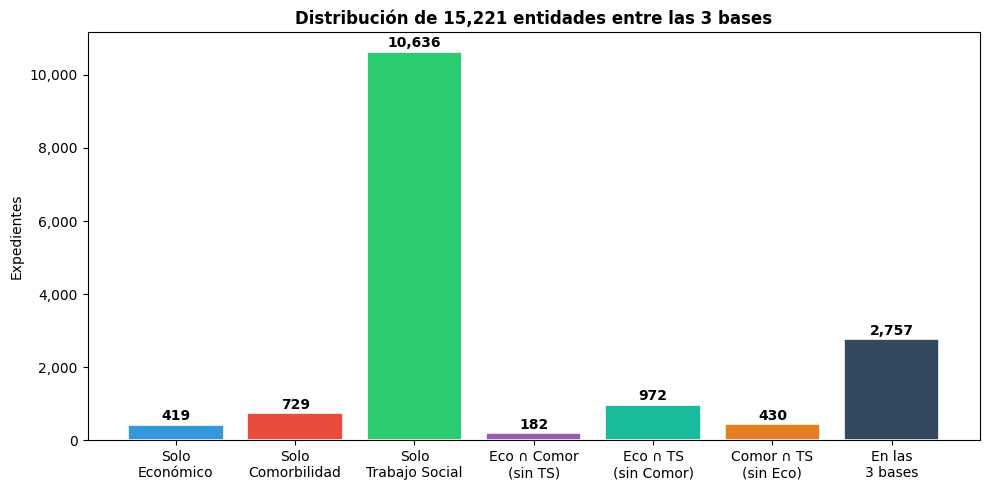

In [42]:
exp_all_3          = exp_econ_v2 & exp_comor_v2 & exp_ts_v2
exp_eco_comor_only = (exp_econ_v2 & exp_comor_v2) - exp_ts_v2
exp_eco_ts_only    = (exp_econ_v2 & exp_ts_v2)    - exp_comor_v2
exp_comor_ts_only  = (exp_comor_v2 & exp_ts_v2)   - exp_econ_v2
exp_eco_only       = exp_econ_v2  - exp_comor_v2 - exp_ts_v2
exp_comor_only     = exp_comor_v2 - exp_econ_v2  - exp_ts_v2
exp_ts_only        = exp_ts_v2    - exp_econ_v2  - exp_comor_v2
total_entidades    = len(exp_econ_v2 | exp_comor_v2 | exp_ts_v2)

exp_econ_conf  = {p[0] for p in pares_econ_v2}
exp_comor_conf = {p[0] for p in pares_comor_v2}
exp_ts_conf    = {p[0] for p in pares_ts_v2}

matched_eco_comor = {p[0] for p in (pares_econ_v2 & pares_comor_v2)}
matched_eco_ts    = {p[0] for p in (pares_econ_v2 & pares_ts_v2)}
matched_comor_ts  = {p[0] for p in (pares_comor_v2 & pares_ts_v2)}
matched_all_3     = {p[0] for p in (pares_econ_v2 & pares_comor_v2 & pares_ts_v2)}

conf_eco_comor_only = matched_eco_comor - matched_all_3
conf_eco_ts_only    = matched_eco_ts    - matched_all_3
conf_comor_ts_only  = matched_comor_ts  - matched_all_3
conf_eco_only       = exp_econ_conf  - matched_eco_comor - matched_eco_ts
conf_comor_only     = exp_comor_conf - matched_eco_comor - matched_comor_ts
conf_ts_only        = exp_ts_conf    - matched_eco_ts    - matched_comor_ts

regiones = [
    ('Solo Económico',                          len(exp_eco_only),       len(conf_eco_only)),
    ('Solo Comorbilidad',                        len(exp_comor_only),     len(conf_comor_only)),
    ('Solo Trabajo Social',                      len(exp_ts_only),        len(conf_ts_only)),
    ('Económico ∩ Comorbilidad (sin TS)',        len(exp_eco_comor_only), len(conf_eco_comor_only)),
    ('Económico ∩ Trabajo Social (sin Comor)',   len(exp_eco_ts_only),    len(conf_eco_ts_only)),
    ('Comorbilidad ∩ Trabajo Social (sin Eco)',  len(exp_comor_ts_only),  len(conf_comor_ts_only)),
    ('En las 3 bases',                           len(exp_all_3),          len(matched_all_3)),
    ('TOTAL',                                    total_entidades,         total_entidades),
]

display(
    pd.DataFrame(regiones, columns=['Región', 'Solo EXP', 'EXP + Nombre']).style
    .format({'Solo EXP': '{:,}', 'EXP + Nombre': '{:,}'})
    .bar(subset=['Solo EXP', 'EXP + Nombre'], color='#1428a7', vmin=0)
    .set_caption('Distribución de entidades únicas por región — comparación de llaves')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

labels = [
    'Solo\nEconómico', 'Solo\nComorbilidad', 'Solo\nTrabajo Social',
    'Eco ∩ Comor\n(sin TS)', 'Eco ∩ TS\n(sin Comor)',
    'Comor ∩ TS\n(sin Eco)', 'En las\n3 bases'
]

values = [
    len(conf_eco_only), len(conf_comor_only), len(conf_ts_only),
    len(conf_eco_comor_only), len(conf_eco_ts_only),
    len(conf_comor_ts_only), len(matched_all_3)
]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Expedientes')
ax.set_title(f'Distribución de {total_entidades:,} entidades entre las 3 bases',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(ruta_base / 'Reporte_Consultoría' / 'Figuras' / 'distribucion_entidades_venn.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 5.4 Diagrama de Venn de entidades únicas

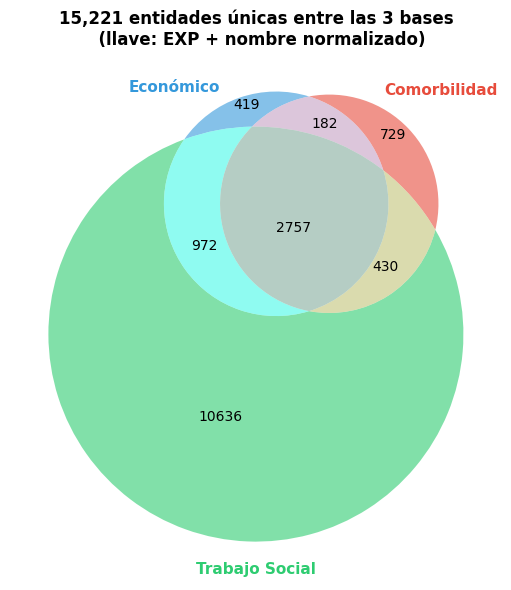

In [52]:
from matplotlib_venn import venn3, venn3_circles

fig, ax = plt.subplots(figsize=(8, 6))

v = venn3(
    subsets=(
        len(conf_eco_only),       # solo Eco
        len(conf_comor_only),     # solo Comor
        len(conf_eco_comor_only), # Eco ∩ Comor (sin TS)
        len(conf_ts_only),        # solo TS
        len(conf_eco_ts_only),    # Eco ∩ TS (sin Comor)
        len(conf_comor_ts_only),  # Comor ∩ TS (sin Eco)
        len(matched_all_3),       # las 3
    ),
    set_labels=('Económico', 'Comorbilidad', 'Trabajo Social'),
    set_colors=('#3498db', '#e74c3c', '#2ecc71'),
    alpha=0.6,
    ax=ax
)

colores_labels = ['#3498db', '#e74c3c', '#2ecc71']
for label, color in zip(v.set_labels, colores_labels):
    if label:
        label.set_color(color)
        label.set_fontweight('bold')
        label.set_fontsize(11)

ax.set_title(f'{total_entidades:,} entidades únicas entre las 3 bases\n  (llave: EXP + nombre normalizado)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ruta_base / 'Reporte_Consultoría' / 'Figuras' / 'venn_entidades.png',
            dpi=250, bbox_inches='tight')
plt.show()


### 5.5 Resumen de dimensionamiento

Se consolidan los resultados de las secciones anteriores en dos niveles: 
* Pares de comparación
* Entidades únicas 

Los 9,855 pares confirmados corresponden a 4,341 entidades vinculables, la diferencia se debe a que una entidad en las 3 bases genera 3 pares distintos. Los 238 expedientes pendientes representan el límite del método automático: casos donde la normalización robusta no fue suficiente para confirmar la vinculación.


In [56]:
n_registros_extra = N_total - total_entidades
entidades_en_2    = len(conf_eco_comor_only) + len(conf_eco_ts_only) + len(conf_comor_ts_only)
entidades_en_3    = len(matched_all_3)
entidades_vinculables = entidades_en_2 + entidades_en_3

exp_pendientes = (
    (exp_econ_v2 & exp_comor_v2) |
    (exp_econ_v2 & exp_ts_v2)    |
    (exp_comor_v2 & exp_ts_v2)
)
exp_pendientes -= {p[0] for p in (pares_econ_v2 & pares_comor_v2)}
exp_pendientes -= {p[0] for p in (pares_econ_v2 & pares_ts_v2)}
exp_pendientes -= {p[0] for p in (pares_comor_v2 & pares_ts_v2)}
n_exp_pendientes = len(exp_pendientes)

ratio = (total_pares - total_pos) / total_pos

# Tabla 1 — nivel de registros
display(
    pd.DataFrame([
        {'Métrica': 'Registros totales (3 CSV)',                              'Valor': f'{N_total:,}'},
        {'Métrica': 'Entidades únicas (EXP + nombre normalizado)',            'Valor': f'{total_entidades:,}'},
        {'Métrica': 'Registros con apariciones duplicadas entre CSV',                       'Valor': f'{n_registros_extra:,}'},
        {'Métrica': 'Entidades presentes en exactamente 2 CSV',              'Valor': f'{entidades_en_2:,}'},
        {'Métrica': 'Entidades presentes en las 3 bases',                    'Valor': f'{entidades_en_3:,}'},
        {'Métrica': 'Total entidades vinculables (en 2 o 3 bases)',          'Valor': f'{entidades_vinculables:,}'},
    ]).style
    .set_caption('Resumen — nivel de registros y entidades')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

# Tabla 2 — nivel de pares
display(
    pd.DataFrame([
        {'Métrica': 'Espacio total cross-CSV (producto cartesiano)',          'Valor': f'{total_pares:,}'},
        {'Métrica': 'Candidatos — expediente compartido entre 2 CSV',        'Valor': f'{total_candidatos:,}'},
        {'Métrica': 'Pares confirmados — EXP + nombre coinciden',            'Valor': f'{total_pos:,}'},
        {'Métrica': 'Pares pendientes — EXP igual, nombre distinto',         'Valor': f'{total_sin_confirmar:,}'},
        {'Métrica': 'Expedientes únicos pendientes (sin doble conteo)',       'Valor': f'{n_exp_pendientes:,}'},
        {'Métrica': 'Desbalance negativos:positivos (espacio total)',         'Valor': f'{ratio:,.0f}:1'},
    ]).style
    .set_caption('Resumen — nivel de pares (verdad base para Record Linkage)')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)


Métrica,Valor
Registros totales (3 CSV),"23,706"
Entidades únicas (EXP + nombre normalizado),"15,221"
Registros con apariciones duplicadas entre CSV,"8,485"
Entidades presentes en exactamente 2 CSV,"1,584"
Entidades presentes en las 3 bases,"2,757"
Total entidades vinculables (en 2 o 3 bases),"4,341"


Métrica,Valor
Espacio total cross-CSV (producto cartesiano),"151,648,056"
Candidatos — expediente compartido entre 2 CSV,"11,424"
Pares confirmados — EXP + nombre coinciden,"9,855"
"Pares pendientes — EXP igual, nombre distinto","1,569"
Expedientes únicos pendientes (sin doble conteo),238
Desbalance negativos:positivos (espacio total),"15,387:1"


## 6. Conclusiones

El análisis confirma que los 3 CSV comparten una fracción significativa de pacientes. Con la llave EXP + nombre normalizado se identificaron **4,341 entidades vinculables** entre bases: 2,757 presentes en las 3 y 1,584 en exactamente 2.

El análisis realizado detectó 2 puntos clave:

* **Corrección de normalización:** La normalización robusta (versión 2) aumentó los matches de Comorbilidad de ~1 a ~2,939 (Eco↔Comor) y de ~16 a ~3,187 (Comor↔TS), corrigiendo el sesgo por encoding roto (`?`→`Ñ`) y orden de tokens. Obteniendo así **9,855 pares confirmados**.

* **Discrepancias residuales:** 1,569 **expedientes compartidos con nombre diferente** tras normalización.
Estos 1,569 pares corresponden a **238 expedientes únicos con nombre distinto**, pues un mismo expediente puede aparecer en más de un cruce, generando doble conteo en la suma de pares, estos registros representan el límite del método automático y requieren revisión manual, se exportan en la sección siguiente.

---

### Conexión con la Estrategia de Entrenamiento

**Fase 0 — Verdad Base:**
- Los **9,855 pares confirmados** (EXP + nombre) constituyen la **extracción básica** (reglas deterministas con llave EXP + nombre normalizado)
- Los **1,569 pares con expediente igual pero nombre diferente** son candidatos para **extracción avanzada** vía Sentence-BERT Zero-Shot 
- La **revisión humana experta** sobre estos 1,569 casos consolidará la Verdad Base definitiva

**Data Augmentation:** Dado el desbalance extremo de ~15,387:1 (negativos:positivos en el espacio total cross-CSV):

- Los 9,855 positivos naturales son insuficientes para entrenar con significancia estadística
- Se requiere generar **pares positivos sintéticos** para cada partición (Train/Val/Test) mediante las técnicas definidas:
  - *Span Deletion*, *Block Shuffling*, *Typo Injection*, *Attribute Masking*, *Input Swapping*
- Los negativos se obtienen eficientemente con in-batch negatives (MNRL) y hard-negative mining

**Partición a nivel de entidad:** Las entidades en las 3 bases + las entidades en 2 bases se particionan ANTES de augmentation. Ningún registro de la misma entidad puede aparecer en particiones diferentes.

### Siguiente paso

Con el dimensionamiento cuantificado, el siguiente paso es la **serialización** de los registros utilizando la estrategia de los bloques semánticos (`[BLK_ID]`, `[BLK_CLIN]`, etc.) y el esquema definido.

## 7. Exportación de Pares Residuales para Revisión Manual

Los 1,569 pares con **mismo expediente pero nombre diferente** tras normalización robusta requieren confirmación humana para determinar si corresponden a la misma entidad. Se exportan aquí con el contexto suficiente para que el comité pueda decidir.

In [58]:
ruta_salida_base = ruta_datos

meta_comparaciones = [
    ('Económico',    'Comorbilidad',   econ_v,  comor_v,  'NOMBRE_DEL_PACIENTE', 'nombre'),
    ('Económico',    'Trabajo Social', econ_v,  ts_v,     'NOMBRE_DEL_PACIENTE', 'nombre_v2'),
    ('Comorbilidad', 'Trabajo Social', comor_v, ts_v,     'nombre',              'nombre_v2'),
]

resumen_export = []

for nombre_a, nombre_b, df_a, df_b, raw_col_a, raw_col_b in meta_comparaciones:
    par_a = set(zip(df_a['EXP_int'], df_a['nombre_v2']))
    par_b = set(zip(df_b['EXP_int'], df_b['nombre_v2']))

    exp_shared     = {p[0] for p in par_a} & {p[0] for p in par_b}
    exp_matched    = {p[0] for p in (par_a & par_b)}
    exp_residuales = exp_shared - exp_matched

    nombres_a = df_a.groupby('EXP_int')[raw_col_a].apply(lambda s: ' | '.join(s.dropna().unique())).to_dict()
    nombres_b = df_b.groupby('EXP_int')[raw_col_b].apply(lambda s: ' | '.join(s.dropna().unique())).to_dict()
    norm_a    = df_a.groupby('EXP_int')['nombre_v2'].apply(lambda s: ' | '.join(s.dropna().unique())).to_dict()
    norm_b    = df_b.groupby('EXP_int')['nombre_v2'].apply(lambda s: ' | '.join(s.dropna().unique())).to_dict()

    filas = []
    for exp in sorted(exp_residuales):
        filas.append({
            'expediente':              exp,
            f'nombre_{nombre_a}':      nombres_a.get(exp, ''),
            f'nombre_{nombre_b}':      nombres_b.get(exp, ''),
            f'nombre_norm_{nombre_a}': norm_a.get(exp, ''),
            f'nombre_norm_{nombre_b}': norm_b.get(exp, ''),
            'misma_entidad':           '',
            'observaciones':           '',
        })

    df_cruce = pd.DataFrame(filas)
    nombre_archivo = f'pares_residuales_{nombre_a.lower().replace(" ", "_")}_{nombre_b.lower().replace(" ", "_")}.csv'
    ruta_salida = ruta_salida_base / nombre_archivo
    df_cruce.to_csv(ruta_salida, index=False, encoding='utf-8-sig')

    resumen_export.append({'Cruce': f'{nombre_a} ↔ {nombre_b}', 'Pares exportados': len(df_cruce), 'Archivo': nombre_archivo})

    display(
        df_cruce.head(4).style
        .set_caption(f'Muestra — {nombre_a} ↔ {nombre_b}')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.0em; font-weight:bold'}])
        .hide(axis='index')
    )

resumen_export.append({'Cruce': 'TOTAL', 'Pares exportados': sum(r['Pares exportados'] for r in resumen_export), 'Archivo': '—'})
display(
    pd.DataFrame(resumen_export).style
    .set_caption('Pares residuales exportados por cruce')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)


expediente,nombre_Económico,nombre_Comorbilidad,nombre_norm_Económico,nombre_norm_Comorbilidad,misma_entidad,observaciones
86078,VEGA MARTINEZ ANA MARIA,ANA VEGA MARTINEZ,ANA MARIA MARTINEZ VEGA,ANA MARTINEZ VEGA,,
90523,CANALES DE LA PARRA EDUARDO,EDUARDO CANALES DE LA PARR,CANALES DE EDUARDO LA PARRA,CANALES DE EDUARDO LA PARR,,
91472,DEL RIO SILVA JORGE ANTONIO,JORGE DEL RIO SILVA,ANTONIO DEL JORGE RIO SILVA,DEL JORGE RIO SILVA,,
125773,CHAPELA MENDOZA MARIA DEL ROCIO,MARIA CHAPELA MENDOZA,CHAPELA DEL MARIA MENDOZA ROCIO,CHAPELA MARIA MENDOZA,,


expediente,nombre_Económico,nombre_Trabajo Social,nombre_norm_Económico,nombre_norm_Trabajo Social,misma_entidad,observaciones
237346,GONZALEZ GUTIERREZ FELIPE,FELIPE GONZALEZ GUTIERREZ MELITON,FELIPE GONZALEZ GUTIERREZ,FELIPE GONZALEZ GUTIERREZ MELITON,,
237415,BARRIOS ARTEAGA MANUEL,ANTONIO ARTEAGA BARRIOS MANUEL,ARTEAGA BARRIOS MANUEL,ANTONIO ARTEAGA BARRIOS MANUEL,,
237461,PAZ GOMEZ JULIA,GOMES JULIA PAZ,GOMEZ JULIA PAZ,GOMES JULIA PAZ,,
237471,DAMIAN CORDOBA RODRIGO,CORDOVA DAMIAN RODRIGO,CORDOBA DAMIAN RODRIGO,CORDOVA DAMIAN RODRIGO,,


expediente,nombre_Comorbilidad,nombre_Trabajo Social,nombre_norm_Comorbilidad,nombre_norm_Trabajo Social,misma_entidad,observaciones
236536,JOSUE RAMIREZ MAURO,JOSUE MAURO NATHANAEL RAMIREZ,JOSUE MAURO RAMIREZ,JOSUE MAURO NATHANAEL RAMIREZ,,
237346,FELIPE GONZALEZ GUTIERREZ,FELIPE GONZALEZ GUTIERREZ MELITON,FELIPE GONZALEZ GUTIERREZ,FELIPE GONZALEZ GUTIERREZ MELITON,,
237414,JOSE NUÑEZ FLORES,ANTONIO FLORES JOSE NUNEZ,FLORES JOSE NUNEZ,ANTONIO FLORES JOSE NUNEZ,,
237460,JULIETH PALOMARES FLORES,CHARLOTE FLORES JULIETH PALOMARES,FLORES JULIETH PALOMARES,CHARLOTE FLORES JULIETH PALOMARES,,


Cruce,Pares exportados,Archivo
Económico ↔ Comorbilidad,690,pares_residuales_económico_comorbilidad.csv
Económico ↔ Trabajo Social,266,pares_residuales_económico_trabajo_social.csv
Comorbilidad ↔ Trabajo Social,613,pares_residuales_comorbilidad_trabajo_social.csv
TOTAL,1569,—
